In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertModel
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
)
import seaborn as sns

In [ ]:
SEED          = 42
MAX_LENGTH    = 64     
BATCH_SIZE    = 16     
EPOCHS        = 10
PATIENCE      = 2      
DROPOUT       = 0.3    

FINE_TUNE     = False          
LR_HEAD       = 1e-3           

DATA_DIR      = "../data"
MODELS_DIR    = "../models"
SAVE_PATH     = os.path.join(MODELS_DIR, "best_bert.pth")

TEXT_COLUMN   = "message"      
LABEL_COLUMN  = "label"

MODEL_NAME    = "distilbert-base-uncased"   

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
train_df = pd.read_csv(os.path.join(DATA_DIR, "train_balanced.csv"))
val_df   = pd.read_csv(os.path.join(DATA_DIR, "validation.csv"))
test_df  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer loaded: {MODEL_NAME}")

Train: 1227 | Val: 760 | Test: 760
Tokenizer loaded: distilbert-base-uncased


c:\Users\chahi\Desktop\AIML\aiml-env\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [ ]:

class SMSDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length):
        self.texts     = dataframe[TEXT_COLUMN].astype(str).tolist()
        self.labels    = (dataframe[LABEL_COLUMN] == "spam").astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.float32),
        }


train_dataset = SMSDataset(train_df, tokenizer, MAX_LENGTH)
val_dataset   = SMSDataset(val_df,   tokenizer, MAX_LENGTH)
test_dataset  = SMSDataset(test_df,  tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

In [ ]:

class BertSpamClassifier(nn.Module):
    def __init__(self, model_name, dropout=0.3, fine_tune=False):
        super().__init__()

        self.bert = DistilBertModel.from_pretrained(model_name)

        if not fine_tune:
            for param in self.bert.parameters():
                param.requires_grad = False

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(768, 1)

    def forward(self, input_ids, attention_mask):
        output = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        cls_vector = output.last_hidden_state[:, 0, :]

        return self.fc(self.dropout(cls_vector)).squeeze(-1)


model = BertSpamClassifier(
    model_name=MODEL_NAME,
    dropout=FINE_TUNE,
    fine_tune=FINE_TUNE,
).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}  (fine_tune={FINE_TUNE})")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

c:\Users\chahi\Desktop\AIML\aiml-env\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\chahi\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Trainable params: 769 / 66,363,649  (fine_tune=False)


In [6]:
if FINE_TUNE:
    optimizer = torch.optim.AdamW([
        {"params": model.bert.parameters(), "lr": LR_BERT},
        {"params": model.fc.parameters(),   "lr": LR_HEAD},
    ])
else:
    optimizer = torch.optim.AdamW(model.fc.parameters(), lr=LR_HEAD)

criterion = nn.BCEWithLogitsLoss()


Starting training (fine_tune=False) ...
Epoch 01/10 | Train Loss: 0.4045 | Val Loss: 0.2059
Epoch 02/10 | Train Loss: 0.2030 | Val Loss: 0.1378
Epoch 03/10 | Train Loss: 0.1473 | Val Loss: 0.1067
Epoch 04/10 | Train Loss: 0.1210 | Val Loss: 0.0798
Epoch 05/10 | Train Loss: 0.1069 | Val Loss: 0.0803
Epoch 06/10 | Train Loss: 0.0957 | Val Loss: 0.0858
Early stopping at epoch 6

Best epoch: 4 — model saved to ../models\best_bert.pth


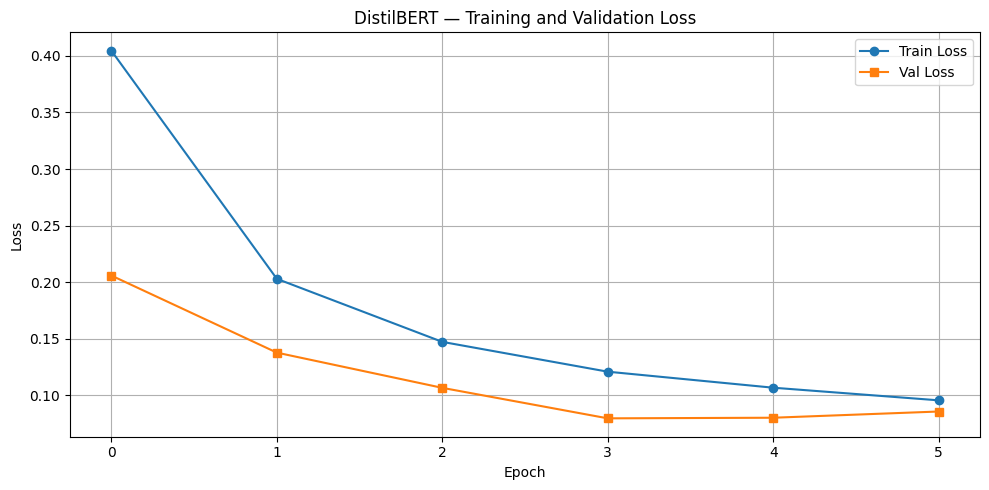

In [ ]:

def calculate_val_loss(model, loader):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["label"].to(device)
            logits         = model(input_ids, attention_mask)
            total         += criterion(logits, labels).item()
    return total / len(loader)


train_losses = []
val_losses   = []
best_val_loss = float("inf")
best_state    = None
best_epoch    = 0
no_improve    = 0

print(f"\nStarting training (fine_tune={FINE_TUNE}) ...")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for batch in train_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    val_loss   = calculate_val_loss(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch    = epoch + 1
        best_state    = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        no_improve    = 0
    else:
        no_improve += 1

    if no_improve >= PATIENCE:
        print(f"Early stopping at epoch {epoch + 1}")
        break

model.load_state_dict(best_state)
os.makedirs(MODELS_DIR, exist_ok=True)
torch.save(best_state, SAVE_PATH)
print(f"\nBest epoch: {best_epoch} — model saved to {SAVE_PATH}")

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss", marker="o")
plt.plot(val_losses,   label="Val Loss",   marker="s")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DistilBERT — Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


--- Test Set Evaluation ---
Accuracy : 0.9803
Precision: 0.9294
Recall   : 0.8977
F1-Score : 0.9133

              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       672
        Spam       0.93      0.90      0.91        88

    accuracy                           0.98       760
   macro avg       0.96      0.94      0.95       760
weighted avg       0.98      0.98      0.98       760



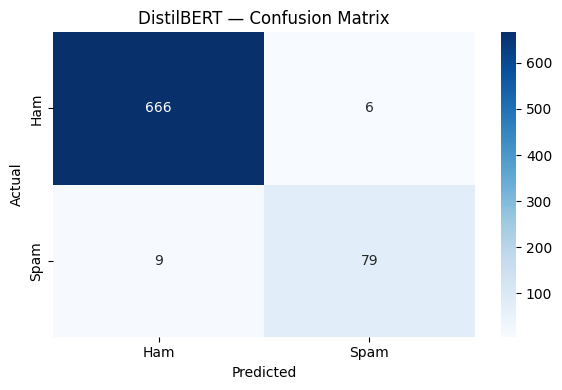

In [8]:

print("\n--- Test Set Evaluation ---")

model.eval()
all_probs  = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"]

        logits = model(input_ids, attention_mask)
        probs  = torch.sigmoid(logits).cpu().numpy()

        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
preds      = (all_probs >= 0.5).astype(int)

acc  = accuracy_score(all_labels, preds)
prec = precision_score(all_labels, preds, zero_division=0)
rec  = recall_score(all_labels, preds, zero_division=0)
f1   = f1_score(all_labels, preds, zero_division=0)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")
print()
print(classification_report(all_labels, preds, target_names=["Ham", "Spam"], zero_division=0))

# Confusion matrix
cm = confusion_matrix(all_labels, preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("DistilBERT — Confusion Matrix")
plt.tight_layout()
plt.show()